<a href="https://colab.research.google.com/github/pantherer/DSA-Assignment/blob/main/topic_modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q uninstall -y gensim scipy numpy pyLDAvis wordcloud

!pip -q install --no-cache-dir --force-reinstall \
  "numpy==1.26.4" \
  "scipy==1.12.0" \
  "pandas==2.2.2" \
  "gensim==4.3.2" \
  "nltk==3.8.1" \
  "pyLDAvis==3.4.1" \
  "wordcloud==1.9.3"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 76.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 272.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 199.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 228.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 256.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.2/113.2 kB 172.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 305.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.8/37.8 MB 189.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 294.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 384.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 247.9 

In [ ]:
import numpy, scipy, pandas
print("numpy:", numpy.__version__)
print("scipy:", scipy.__version__)
print("pandas:", pandas.__version__)


numpy: 1.26.4
scipy: 1.12.0
pandas: 2.2.2


In [ ]:
from gensim import corpora
from gensim.utils import simple_preprocess
from gensim.models import LdaModel, CoherenceModel
from gensim.models.phrases import Phrases, Phraser

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

print("✅ Gensim + NLTK imports working")


✅ Gensim + NLTK imports working


In [ ]:
import os
os.listdir("/content")


['.config', 'abcnews-date-text.csv', 'sample_data']

In [ ]:
import pandas as pd

df = pd.read_csv("/content/abcnews-date-text.csv")

print("Columns:", df.columns.tolist())
print("Rows:", len(df))
df.head()


Columns: ['publish_date', 'headline_text']
Rows: 63765


,publish_date,headline_text
0,20030219,aba decides against community broadcasting lic...
1,20030219,act fire witnesses must be aware of defamation
2,20030219,a g calls for infrastructure protection summit
3,20030219,air nz staff in aust strike for pay rise
4,20030219,air nz strike to affect australian travellers


In [ ]:
# ============================================================
# High-Evidence Topic Modelling Pipeline (Gensim + Sklearn)
# Assumes df is already loaded from /content/abcnews-date-text.csv
# ============================================================

import re, os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from gensim import corpora
from gensim.utils import simple_preprocess
from gensim.models import LdaModel, CoherenceModel
from gensim.models.phrases import Phrases, Phraser

from sklearn.decomposition import TruncatedSVD, NMF
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer


In [ ]:
# ----------------------------
# NLTK downloads
# ----------------------------
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

True

In [ ]:
# ----------------------------
# Reproducibility
# ----------------------------
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

In [ ]:


# ----------------------------
# 1) Config
# ----------------------------
TEXT_COL = "headline_text"
DATE_COL = "publish_date"  # optional

SAMPLE_SIZE = 50000
NO_BELOW = 20
NO_ABOVE = 0.5

K_START = 6
K_LIMIT = 30
K_STEP  = 3

BASELINE_PASSES_SWEEP = 2
FINAL_PASSES = 12
CHUNKSIZE = 2000

USE_TRIGRAMS = False   # keep False for speed/stability

In [ ]:
# ----------------------------
# 2) Sampling + cleaning
# ----------------------------
df = df.dropna(subset=[TEXT_COL]).copy()
df[TEXT_COL] = df[TEXT_COL].astype(str)

if len(df) > SAMPLE_SIZE:
    df = df.sample(SAMPLE_SIZE, random_state=GLOBAL_SEED)

def clean_text_basic(text: str) -> str:
    text = str(text).strip().lower()
    text = re.sub(r"\s+", " ", text)
    return text

df[TEXT_COL] = df[TEXT_COL].apply(clean_text_basic)
print("Rows used:", len(df))

Rows used: 50000


In [ ]:
# ----------------------------
# 3) Tokenization + stopwords + lemmatization
# ----------------------------
stop_words = set(stopwords.words("english"))
lemm = WordNetLemmatizer()

def tokenize(text: str):
    return simple_preprocess(text, deacc=True, min_len=2)

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words and len(t) > 2]

def lemmatize(tokens):
    return [lemm.lemmatize(t) for t in tokens]

tokens = []
for t in df[TEXT_COL].tolist():
    toks = tokenize(t)
    toks = remove_stopwords(toks)
    toks = lemmatize(toks)
    tokens.append(toks)

print("Token sample:", tokens[:2])

Token sample: [['third', 'time', 'lucky', 'canberra', 'unis', 'brisbane', 'campus'], ['latif', 'go', 'easy', 'akhtar']]


In [ ]:
# ============================================================
# COMMON METHODOLOGY
# 4) Baseline LDA with UNIGRAMS
# ============================================================

tokens_uni = tokens

dictionary_uni = corpora.Dictionary(tokens_uni)
dictionary_uni.filter_extremes(no_below=NO_BELOW, no_above=NO_ABOVE)
corpus_uni = [dictionary_uni.doc2bow(doc) for doc in tokens_uni]

print("Baseline dictionary size:", len(dictionary_uni))


Baseline dictionary size: 2293


In [ ]:
# ----------------------------
# 5) K-sweep function
# ----------------------------
def k_sweep(dictionary, corpus, texts, start=6, limit=30, step=3, passes=2, label="model"):
    results = []
    models = []
    print(f"\nStarting K-Sweep for {label}...")

    for k in range(start, limit + 1, step):
        lda = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=k,
            random_state=GLOBAL_SEED,
            chunksize=CHUNKSIZE,
            passes=passes,
            alpha="auto",
            per_word_topics=True
        )
        cm = CoherenceModel(model=lda, texts=texts, dictionary=dictionary, coherence="c_v")
        cv = cm.get_coherence()
        results.append((k, cv))
        models.append(lda)
        print(f"{label} K={k} -> c_v={cv:.4f}")

    return results, models


Starting K-Sweep for Baseline LDA (unigrams)...
Baseline LDA (unigrams) K=6 -> c_v=0.3088
Baseline LDA (unigrams) K=9 -> c_v=0.3429
Baseline LDA (unigrams) K=12 -> c_v=0.3726
Baseline LDA (unigrams) K=15 -> c_v=0.3875
Baseline LDA (unigrams) K=18 -> c_v=0.4577
Baseline LDA (unigrams) K=21 -> c_v=0.4637
Baseline LDA (unigrams) K=24 -> c_v=0.4860
Baseline LDA (unigrams) K=27 -> c_v=0.5239
Baseline LDA (unigrams) K=30 -> c_v=0.5299

Best baseline K: 30 c_v: 0.5298517838570981


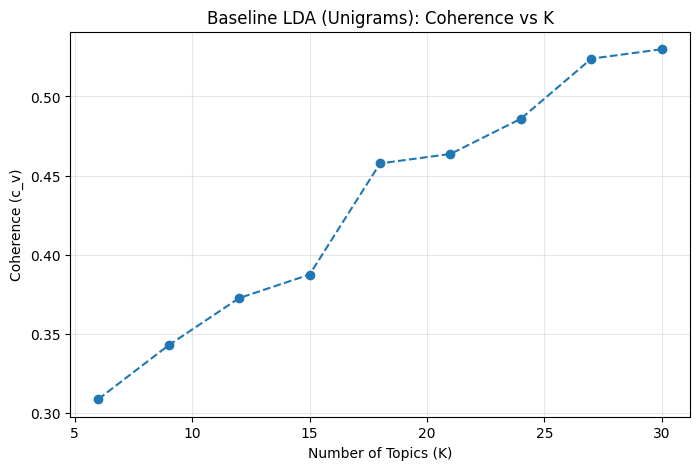

In [ ]:
# ----------------------------
# 6) Baseline sweep + plot
# ----------------------------
baseline_results, baseline_models = k_sweep(
    dictionary_uni, corpus_uni, tokens_uni,
    start=K_START, limit=K_LIMIT, step=K_STEP,
    passes=BASELINE_PASSES_SWEEP, label="Baseline LDA (unigrams)"
)

best_k_uni, best_cv_uni = sorted(baseline_results, key=lambda x: x[1], reverse=True)[0]
print("\nBest baseline K:", best_k_uni, "c_v:", best_cv_uni)

ks, cvs = zip(*baseline_results)
plt.figure(figsize=(8,5))
plt.plot(ks, cvs, marker="o", linestyle="--")
plt.xlabel("Number of Topics (K)")
plt.ylabel("Coherence (c_v)")
plt.title("Baseline LDA (Unigrams): Coherence vs K")
plt.grid(True, alpha=0.3)
plt.savefig("coherence_baseline.png")
plt.show()

In [ ]:
# ----------------------------
# 7) Train final baseline LDA
# ----------------------------
lda_baseline = LdaModel(
    corpus=corpus_uni,
    id2word=dictionary_uni,
    num_topics=best_k_uni,
    random_state=GLOBAL_SEED,
    chunksize=CHUNKSIZE,
    passes=FINAL_PASSES,
    alpha="auto",
    per_word_topics=True
)

def topics_to_df(lda_model, num_words=12):
    rows = []
    for topic_id in range(lda_model.num_topics):
        words = lda_model.show_topic(topic_id, topn=num_words)
        rows.append({
            "topic_id": topic_id,
            "top_words": ", ".join([w for w, _ in words])
        })
    return pd.DataFrame(rows)

topics_baseline_df = topics_to_df(lda_baseline, 12)
topics_baseline_df.to_csv("topics_baseline.csv", index=False)
print("Saved topics_baseline.csv")

Saved topics_baseline.csv


In [ ]:
# ============================================================
# INDIVIDUAL TECHNIQUE
# 8) Improved LDA with BIGRAMS (optional TRIGRAMS)
# ============================================================

print("\nBuilding bigrams for individual technique...")

bigram = Phrases(tokens, min_count=10, threshold=30)
bigram_mod = Phraser(bigram)
tokens_bi = [bigram_mod[doc] for doc in tokens]

if USE_TRIGRAMS:
    print("Building trigrams...")
    trigram = Phrases(tokens_bi, min_count=8, threshold=25)
    trigram_mod = Phraser(trigram)
    tokens_bi = [trigram_mod[doc] for doc in tokens_bi]

dictionary_bi = corpora.Dictionary(tokens_bi)
dictionary_bi.filter_extremes(no_below=NO_BELOW, no_above=NO_ABOVE)
corpus_bi = [dictionary_bi.doc2bow(doc) for doc in tokens_bi]

print("Improved dictionary size:", len(dictionary_bi))



Building bigrams for individual technique...
Improved dictionary size: 2359



Starting K-Sweep for Improved LDA (bigrams)...
Improved LDA (bigrams) K=6 -> c_v=0.3389
Improved LDA (bigrams) K=9 -> c_v=0.3953
Improved LDA (bigrams) K=12 -> c_v=0.4269
Improved LDA (bigrams) K=15 -> c_v=0.4397
Improved LDA (bigrams) K=18 -> c_v=0.4769
Improved LDA (bigrams) K=21 -> c_v=0.4994
Improved LDA (bigrams) K=24 -> c_v=0.5232
Improved LDA (bigrams) K=27 -> c_v=0.5472
Improved LDA (bigrams) K=30 -> c_v=0.5657

Best improved K: 30 c_v: 0.5657278611848403


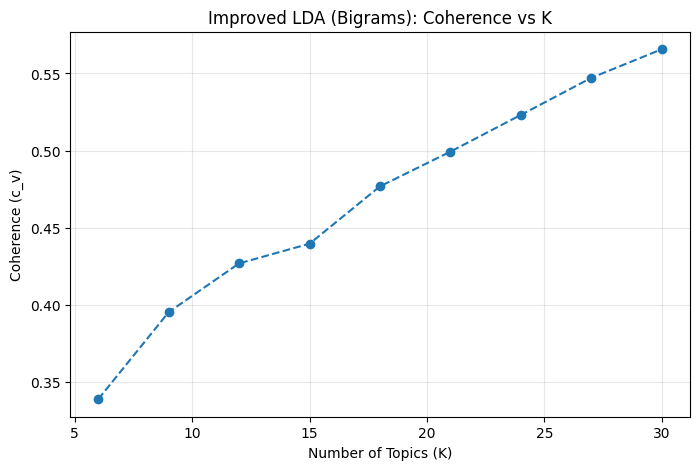

In [ ]:
# ----------------------------
# 9) Improved sweep + plot
# ----------------------------
improved_results, improved_models = k_sweep(
    dictionary_bi, corpus_bi, tokens_bi,
    start=K_START, limit=K_LIMIT, step=K_STEP,
    passes=BASELINE_PASSES_SWEEP, label="Improved LDA (bigrams)"
)

best_k_bi, best_cv_bi = sorted(improved_results, key=lambda x: x[1], reverse=True)[0]
print("\nBest improved K:", best_k_bi, "c_v:", best_cv_bi)

ks2, cvs2 = zip(*improved_results)
plt.figure(figsize=(8,5))
plt.plot(ks2, cvs2, marker="o", linestyle="--")
plt.xlabel("Number of Topics (K)")
plt.ylabel("Coherence (c_v)")
plt.title("Improved LDA (Bigrams): Coherence vs K")
plt.grid(True, alpha=0.3)
plt.savefig("coherence_improved.png")
plt.show()

In [ ]:
# ----------------------------
# 10) Train final improved LDA
# ----------------------------
lda_improved = LdaModel(
    corpus=corpus_bi,
    id2word=dictionary_bi,
    num_topics=best_k_bi,
    random_state=GLOBAL_SEED,
    chunksize=CHUNKSIZE,
    passes=FINAL_PASSES,
    alpha="auto",
    per_word_topics=True
)

topics_improved_df = topics_to_df(lda_improved, 12)
topics_improved_df.to_csv("topics_improved.csv", index=False)
print("Saved topics_improved.csv")

Saved topics_improved.csv


In [ ]:
# ============================================================
# 11) EXTRA COMMON BASELINES: LSA + NMF
# ============================================================

print("\nRunning LSA + NMF baselines for stronger rigour...")

docs_joined_uni = [" ".join(doc) for doc in tokens_uni]

def get_topics_sklearn(model, feature_names, n_top_words=12):
    topics = []
    for comp in model.components_:
        top_idx = np.argsort(comp)[-n_top_words:][::-1]
        topics.append([feature_names[i] for i in top_idx])
    return topics

def coherence_for_topics(topics, texts, dictionary):
    cm = CoherenceModel(topics=topics, texts=texts, dictionary=dictionary, coherence="c_v")
    return cm.get_coherence()

# LSA
cvect = CountVectorizer(max_df=NO_ABOVE, min_df=NO_BELOW)
X_counts = cvect.fit_transform(docs_joined_uni)
count_names = cvect.get_feature_names_out()

lsa_k = best_k_uni
lsa = TruncatedSVD(n_components=lsa_k, random_state=GLOBAL_SEED)
lsa.fit(X_counts)

lsa_topics = get_topics_sklearn(lsa, count_names, 12)
lsa_cv = coherence_for_topics(lsa_topics, tokens_uni, dictionary_uni)
print(f"LSA coherence (c_v approx): {lsa_cv:.4f}")

# NMF
tfidf = TfidfVectorizer(max_df=NO_ABOVE, min_df=NO_BELOW)
X_tfidf = tfidf.fit_transform(docs_joined_uni)
tfidf_names = tfidf.get_feature_names_out()

nmf_k = best_k_uni
nmf = NMF(n_components=nmf_k, random_state=GLOBAL_SEED, init="nndsvda", max_iter=400)
nmf.fit(X_tfidf)

nmf_topics = get_topics_sklearn(nmf, tfidf_names, 12)
nmf_cv = coherence_for_topics(nmf_topics, tokens_uni, dictionary_uni)
print(f"NMF coherence (c_v approx): {nmf_cv:.4f}")


Running LSA + NMF baselines for stronger rigour...
LSA coherence (c_v approx): 0.2381
NMF coherence (c_v approx): 0.3523


In [ ]:
# ============================================================
# 12) Topic Diversity
# ============================================================

def topic_diversity(lda_model, topn=25):
    all_words = []
    for t in range(lda_model.num_topics):
        all_words.extend([w for w, _ in lda_model.show_topic(t, topn=topn)])
    unique = len(set(all_words))
    total = len(all_words)
    return unique / total if total else 0

td_baseline = topic_diversity(lda_baseline)
td_improved = topic_diversity(lda_improved)

print(f"Topic diversity baseline LDA: {td_baseline:.4f}")
print(f"Topic diversity improved LDA: {td_improved:.4f}")


Topic diversity baseline LDA: 0.9880
Topic diversity improved LDA: 0.9973


In [ ]:
# ============================================================
# 13) Stability Test across Random Seeds (FAST + WORKING)
# ============================================================

print("\nRunning FAST stability test across random seeds...")

SEEDS = [1, 42, 77]
STABILITY_PASSES = 3

from gensim.models import LdaMulticore

def train_and_score_fast(seed, dictionary, corpus, texts, k):
    lda = LdaMulticore(
        corpus=corpus,
        id2word=dictionary,
        num_topics=k,
        random_state=seed,
        chunksize=CHUNKSIZE,
        passes=STABILITY_PASSES,
        alpha="symmetric",   # ✅ FIX
        eta="symmetric",     # ✅ stable default
        workers=4,
        per_word_topics=False
    )
    cm = CoherenceModel(model=lda, texts=texts, dictionary=dictionary, coherence="c_v")
    return cm.get_coherence()

stability_rows = []
for s in SEEDS:
    cv_uni = train_and_score_fast(s, dictionary_uni, corpus_uni, tokens_uni, best_k_uni)
    cv_bi  = train_and_score_fast(s, dictionary_bi,  corpus_bi,  tokens_bi,  best_k_bi)
    stability_rows.append({
        "seed": s,
        "baseline_lda_cv": cv_uni,
        "improved_lda_cv": cv_bi
    })

stability_df = pd.DataFrame(stability_rows)
stability_df.to_csv("stability_report.csv", index=False)

print(stability_df)
print("Saved stability_report.csv")



Running FAST stability test across random seeds...
   seed  baseline_lda_cv  improved_lda_cv
0     1         0.476719         0.519117
1    42         0.484742         0.513042
2    77         0.480414         0.514540
Saved stability_report.csv


In [ ]:
# ============================================================
# 13.1) Stability Summary (paste after Step 13)
# ============================================================

# 1) Quick console summary
print("\n================ STABILITY SUMMARY ================")

mean_baseline = stability_df["baseline_lda_cv"].mean()
std_baseline  = stability_df["baseline_lda_cv"].std()

mean_improved = stability_df["improved_lda_cv"].mean()
std_improved  = stability_df["improved_lda_cv"].std()

improvement = mean_improved - mean_baseline

print(f"Baseline LDA (unigrams): mean c_v = {mean_baseline:.4f}, std = {std_baseline:.4f}")
print(f"Improved LDA (bigrams): mean c_v = {mean_improved:.4f}, std = {std_improved:.4f}")
print(f"Mean improvement (bigrams - baseline) = {improvement:.4f}")

# 2) Create a neat table for your report
stability_summary = pd.DataFrame({
    "Model": ["Baseline LDA (unigrams)", "Improved LDA (bigrams)"],
    "Mean_c_v": [mean_baseline, mean_improved],
    "Std_c_v": [std_baseline, std_improved],
    "Seeds_Used": [", ".join(map(str, SEEDS)), ", ".join(map(str, SEEDS))],
    "Stability_Passes": [STABILITY_PASSES, STABILITY_PASSES]
})

print("\n--- Stability Summary Table ---")
print(stability_summary)

# 3) Save for appendix/results
stability_summary.to_csv("stability_summary.csv", index=False)
print("\nSaved stability_summary.csv")

# 4) (Optional) Add stability stats into method_comparison.csv
#    This only runs if that file already exists.
if os.path.exists("method_comparison.csv"):
    mc = pd.read_csv("method_comparison.csv")

    # Add new columns if not present
    for col in ["Mean_c_v_Stability", "Std_c_v_Stability"]:
        if col not in mc.columns:
            mc[col] = np.nan

    # Update rows for baseline & improved if matched by text
    mc.loc[mc["Method"].str.contains("Baseline LDA", case=False, na=False), "Mean_c_v_Stability"] = mean_baseline
    mc.loc[mc["Method"].str.contains("Baseline LDA", case=False, na=False), "Std_c_v_Stability"]  = std_baseline

    mc.loc[mc["Method"].str.contains("Improved LDA", case=False, na=False), "Mean_c_v_Stability"] = mean_improved
    mc.loc[mc["Method"].str.contains("Improved LDA", case=False, na=False), "Std_c_v_Stability"]  = std_improved

    mc.to_csv("method_comparison.csv", index=False)
    print("Updated method_comparison.csv with stability stats ✅")
else:
    print("method_comparison.csv not found yet — skipping merge.")



================ STABILITY SUMMARY ================
Baseline LDA (unigrams): mean c_v = 0.4806, std = 0.0040
Improved LDA (bigrams): mean c_v = 0.5156, std = 0.0032
Mean improvement (bigrams - baseline) = 0.0349

--- Stability Summary Table ---
                     Model  Mean_c_v   Std_c_v Seeds_Used  Stability_Passes
0  Baseline LDA (unigrams)  0.480625  0.004016  1, 42, 77                 3
1   Improved LDA (bigrams)  0.515566  0.003165  1, 42, 77                 3

Saved stability_summary.csv
method_comparison.csv not found yet — skipping merge.


In [ ]:
# ============================================================
# 14) Method Comparison Table (create if missing)
#     Includes stability mean/std for LDA models
# ============================================================

methods = []
coherences = []
topic_divs = []

# ---- Baseline LDA ----
if "best_k_uni" in globals() and "best_cv_uni" in globals():
    methods.append(f"Baseline LDA (unigrams) K={best_k_uni}")
    coherences.append(best_cv_uni)
    # topic diversity optional
    topic_divs.append(td_baseline if "td_baseline" in globals() else np.nan)

# ---- Improved LDA ----
if "best_k_bi" in globals() and "best_cv_bi" in globals():
    methods.append(f"Improved LDA (bigrams) K={best_k_bi}")
    coherences.append(best_cv_bi)
    topic_divs.append(td_improved if "td_improved" in globals() else np.nan)

# ---- LSA ----
if "lsa_k" in globals() and "lsa_cv" in globals():
    methods.append(f"LSA baseline K={lsa_k}")
    coherences.append(lsa_cv)
    topic_divs.append(np.nan)

# ---- NMF ----
if "nmf_k" in globals() and "nmf_cv" in globals():
    methods.append(f"NMF baseline K={nmf_k}")
    coherences.append(nmf_cv)
    topic_divs.append(np.nan)

# Build base table
comparison_df = pd.DataFrame({
    "Method": methods,
    "Coherence_c_v": coherences,
    "Topic_Diversity": topic_divs
})

# Add stability columns
comparison_df["Mean_c_v_Stability"] = np.nan
comparison_df["Std_c_v_Stability"] = np.nan
comparison_df["Seeds_Used"] = ""
comparison_df["Stability_Passes"] = np.nan

# Fill stability info for LDA rows if stability stats exist
if "mean_baseline" in globals():
    comparison_df.loc[
        comparison_df["Method"].str.contains("Baseline LDA", case=False, na=False),
        "Mean_c_v_Stability"
    ] = mean_baseline

    comparison_df.loc[
        comparison_df["Method"].str.contains("Baseline LDA", case=False, na=False),
        "Std_c_v_Stability"
    ] = std_baseline

if "mean_improved" in globals():
    comparison_df.loc[
        comparison_df["Method"].str.contains("Improved LDA", case=False, na=False),
        "Mean_c_v_Stability"
    ] = mean_improved

    comparison_df.loc[
        comparison_df["Method"].str.contains("Improved LDA", case=False, na=False),
        "Std_c_v_Stability"
    ] = std_improved

if "SEEDS" in globals():
    comparison_df.loc[
        comparison_df["Method"].str.contains("LDA", case=False, na=False),
        "Seeds_Used"
    ] = ", ".join(map(str, SEEDS))

if "STABILITY_PASSES" in globals():
    comparison_df.loc[
        comparison_df["Method"].str.contains("LDA", case=False, na=False),
        "Stability_Passes"
    ] = STABILITY_PASSES

# Sort by coherence
comparison_df = comparison_df.sort_values("Coherence_c_v", ascending=False).reset_index(drop=True)

print("\n=== Method Comparison (with Stability) ===")
print(comparison_df)

comparison_df.to_csv("method_comparison.csv", index=False)
print("\nSaved method_comparison.csv ✅")



=== Method Comparison (with Stability) ===
                         Method  Coherence_c_v  Topic_Diversity  \
0   Improved LDA (bigrams) K=30       0.565728         0.997333   
1  Baseline LDA (unigrams) K=30       0.529852         0.988000   
2             NMF baseline K=30       0.352335              NaN   
3             LSA baseline K=30       0.238055              NaN   

   Mean_c_v_Stability  Std_c_v_Stability Seeds_Used  Stability_Passes  
0            0.515566           0.003165  1, 42, 77               3.0  
1            0.480625           0.004016  1, 42, 77               3.0  
2                 NaN                NaN                          NaN  
3                 NaN                NaN                          NaN  

Saved method_comparison.csv ✅


In [ ]:
import pandas as pd

# Load improved topics
topics_improved = pd.read_csv("topics_improved.csv")

# Inspect
print(topics_improved.head())

# ------------------------------------------------
# Create a compact Table 3 (choose 8–10 topics)
# ------------------------------------------------
# Option A: take first 10 topics (simple)
table3 = topics_improved.head(10).copy()

# Add a manual label column you will fill
table3["proposed_label"] = ""

# Reorder columns nicely
table3 = table3[["topic_id", "proposed_label", "top_words"]]

print("\n--- Table 3 draft (fill proposed_label) ---")
print(table3)

# Save a version you can edit and re-upload if needed
table3.to_csv("table3_topics_improved_draft.csv", index=False)
print("\nSaved table3_topics_improved_draft.csv")


   topic_id                                          top_words
0         0  police, probe, open, protest, still, play, war...
1         1  win, air, concern, push, strike, three, case, ...
2         2  nsw, sydney, troop, kill, meet, blast, palesti...
3         3  worker, job, public, join, meeting, player, co...
4         4  vic, support, put, bid, melbourne, green, coul...

--- Table 3 draft (fill proposed_label) ---
   topic_id proposed_label                                          top_words
0         0                 police, probe, open, protest, still, play, war...
1         1                 win, air, concern, push, strike, three, case, ...
2         2                 nsw, sydney, troop, kill, meet, blast, palesti...
3         3                 worker, job, public, join, meeting, player, co...
4         4                 vic, support, put, bid, melbourne, green, coul...
5         5                 deal, defends, family, pay, british, sign, cos...
6         6                 hea

In [ ]:
pd.set_option("display.max_colwidth", 200)
topics_improved = pd.read_csv("topics_improved.csv")
topics_improved.head(10)


,topic_id,top_words
0,0,"police, probe, open, protest, still, play, warns, launch, blaze, body, arrest, house"
1,1,"win, air, concern, push, strike, three, case, spark, keep, reform, darwin, rebel"
2,2,"nsw, sydney, troop, kill, meet, blast, palestinian, howard, rail, trade, vote, development"
3,3,"worker, job, public, join, meeting, player, consider, wont, issue, education, debate, tiger"
4,4,"vic, support, put, bid, melbourne, green, could, despite, match, anti, church, rally"
5,5,"deal, defends, family, pay, british, sign, cost, national, highlight, delay, conference, save"
6,6,"health, power, study, considers, denies, opposition, black, crime, protester, indian, run, zimbabwe"
7,7,"back, clash, continue, found, local, visit, iran, nuclear, program, sex, turkey, best"
8,8,"govt, plan, council, qld, water, help, decision, work, begin, urge, indigenous, rule"
9,9,"call, boost, home, australian, rain, bomb, port, saddam, gas, pressure, drop, increase"


In [ ]:
import pandas as pd

topics_improved = pd.read_csv("topics_improved.csv")
table3 = topics_improved.head(10).copy()

labels = {
    0: "Policing, crime investigations & public incidents",
    1: "Security, conflict pressure & policy reform signals",
    2: "NSW/Sydney governance with international security overlap",
    3: "Workforce, jobs & public debate",
    4: "Victoria civic politics, activism & public life",
    5: "International politics, public costs & institutional decisions",
    6: "Public health and contested governance narratives",
    7: "International disputes & strategic conflict themes",
    8: "Government planning, water policy & Indigenous governance",
    9: "National economy, environment & major security events",
}

table3["proposed_label"] = table3["topic_id"].map(labels)
table3 = table3[["topic_id", "proposed_label", "top_words"]]

table3.to_csv("table3_topics_improved_filled.csv", index=False)
table3


,topic_id,proposed_label,top_words
0,0,"Policing, crime investigations & public incidents","police, probe, open, protest, still, play, warns, launch, blaze, body, arrest, house"
1,1,"Security, conflict pressure & policy reform signals","win, air, concern, push, strike, three, case, spark, keep, reform, darwin, rebel"
2,2,NSW/Sydney governance with international security overlap,"nsw, sydney, troop, kill, meet, blast, palestinian, howard, rail, trade, vote, development"
3,3,"Workforce, jobs & public debate","worker, job, public, join, meeting, player, consider, wont, issue, education, debate, tiger"
4,4,"Victoria civic politics, activism & public life","vic, support, put, bid, melbourne, green, could, despite, match, anti, church, rally"
5,5,"International politics, public costs & institutional decisions","deal, defends, family, pay, british, sign, cost, national, highlight, delay, conference, save"
6,6,Public health and contested governance narratives,"health, power, study, considers, denies, opposition, black, crime, protester, indian, run, zimbabwe"
7,7,International disputes & strategic conflict themes,"back, clash, continue, found, local, visit, iran, nuclear, program, sex, turkey, best"
8,8,"Government planning, water policy & Indigenous governance","govt, plan, council, qld, water, help, decision, work, begin, urge, indigenous, rule"
9,9,"National economy, environment & major security events","call, boost, home, australian, rain, bomb, port, saddam, gas, pressure, drop, increase"


In [ ]:
table3.to_csv("Table3_Labelled_Topics_Improved_LDA_K30.csv", index=False)
print("Saved Table3_Labelled_Topics_Improved_LDA_K30.csv ✅")


Saved Table3_Labelled_Topics_Improved_LDA_K30.csv ✅
